# Week 6 - UHPC Semantic Missingness and Feature Strategies

This notebook documents the preprocessing strategies I used for the new UHPC dataset in Week 6.

The purpose is not to train the final linear model yet. The purpose is to show how the Week 6 modelling tables were built from the Week 5 UHPC target-filtered dataset, and why each preprocessing decision was made.

The notebook follows the production script:

```text
scripts/run_week06_semantic_missingness.py
```

Main strategies shown here:

1. Keep only rows with a valid 28-day compressive-strength target.
2. Exclude leakage columns and keep only mix-constituent plus curing-regime inputs.
3. Normalize blank text markers and coerce known numeric features.
4. Compare three raw missingness policies: `full_raw`, `raw_le_50`, and `raw_le_20`.
5. Apply semantic amount/type recoding for material pairs.
6. Create reproducible train/validation/test splits.
7. Build train-fitted preprocessing pipelines for numeric and categorical features.
8. Check what is ready for modelling and what should be improved next.


## Presentation route

A good way to present this notebook is:

| Part | Question answered |
|---|---|
| Dataset lineage | Which UHPC rows are usable for the 28-day target? |
| Leakage exclusion | Which columns are safe inputs for modelling? |
| Missingness strategy | When is a blank value actually meaningful? |
| Policy comparison | How much information do we keep under each missingness threshold? |
| Preprocessing | How do we prepare numeric and categorical features without leakage? |
| Limitations | What should be fixed before final model claims? |


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# Locate S1_Linear whether Jupyter starts in the repository root or in S1_Linear/notebooks.
CWD = Path.cwd().resolve()
if CWD.name == "notebooks":
    PROJECT_ROOT = CWD.parent
elif (CWD / "configs" / "week06_semantic_missingness.yaml").exists():
    PROJECT_ROOT = CWD
elif (CWD / "S1_Linear" / "configs" / "week06_semantic_missingness.yaml").exists():
    PROJECT_ROOT = CWD / "S1_Linear"
else:
    candidates = [p / "S1_Linear" for p in CWD.parents]
    PROJECT_ROOT = next(
        p for p in candidates
        if (p / "configs" / "week06_semantic_missingness.yaml").exists()
    )

for path in [PROJECT_ROOT / "src", PROJECT_ROOT, PROJECT_ROOT.parent]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from s1_linear.config import load_config
from s1_linear.feature_policies import (
    TARGET_COLUMN,
    build_week6_preprocessor,
    coerce_numeric_features,
    filter_features_by_missingness,
    make_excluded_columns_table,
    select_week6_candidate_features,
)
from s1_linear.semantic_missingness import (
    NOT_APPLICABLE,
    UNKNOWN_TYPE,
    make_missing_before_after_report,
    normalize_text_missing_values,
    recode_semantic_missingness,
)
from scripts.run_week06_semantic_missingness import (
    keep_valid_target_rows,
    load_week6_source,
    split_train_val_test,
)

CONFIG_PATH = PROJECT_ROOT / "configs" / "week06_semantic_missingness.yaml"
config = load_config(CONFIG_PATH)
target_col = config["data"].get("target", TARGET_COLUMN)

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)
print("Target column:", target_col)


Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear
Config path: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/configs/week06_semantic_missingness.yaml
Target column: Mechanical Properties | Compressive Strength (Mpa) | 28-Day


## Strategy 0 - Use the Week 5 target-filtered UHPC source

Week 5 imported the Excel workbook, preserved the three-level header structure, flattened the names, found the 28-day compressive strength target, and saved rows with a valid target.

Week 6 starts from that cleaned CSV:

```text
data/processed/uhpc_rows_with_28day_target.csv
```

This means Week 6 is focused on feature strategy, not on repeating the Excel import work.

In [2]:
raw_df = load_week6_source(config)
raw_df = normalize_text_missing_values(raw_df)

target_df, target_summary = keep_valid_target_rows(raw_df, target_col)

display(target_summary)
print("Raw Week 6 source shape:", raw_df.shape)
print("Rows used after target filtering:", target_df.shape[0])
print("Columns available:", target_df.shape[1])


,item,value
0,total_rows_in_source,2073.0
1,rows_with_valid_28_day_target,2073.0
2,rows_missing_28_day_target,0.0
3,usable_rows_for_28_day_target_percent,100.0


Raw Week 6 source shape: (2073, 92)
Rows used after target filtering: 2073
Columns available: 92


### Interpretation

The Week 6 source is already target-filtered by Week 5, so the target report shows all rows in this CSV are usable for 28-day compressive-strength modelling.

The original Excel workbook had 2,188 rows. Week 5 found 2,073 rows with a valid 28-day target, so Week 6 works with those 2,073 rows.

## Strategy 1 - Exclude leakage and keep safe input columns

The target is 28-day compressive strength. I should not use columns that are outcomes, test metadata, paper metadata, or identifiers as model predictors.

So Week 6 keeps only columns beginning with:

- `Mix Constitutents |`
- `Curing Regime |`

and excludes columns such as:

- `Mix-ID`
- workability measurements
- other mechanical properties
- durability properties
- research paper details


,item,count
0,all_columns,92
1,candidate_features,42
2,excluded_non_target_columns,49


,reason,excluded_columns
0,mechanical_outcome_or_testing_metadata_leakage,26
1,durability_outcome_leakage,15
2,paper_metadata,4
3,workability_excluded_by_week6_scope,3
4,identifier,1


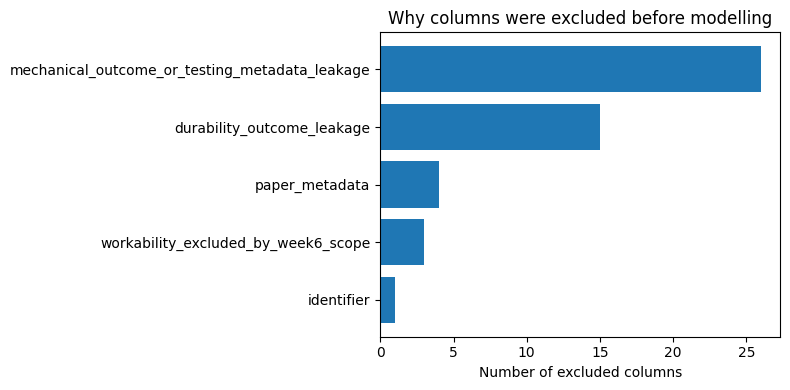

In [3]:
candidate_features = select_week6_candidate_features(target_df, target_col)
excluded_columns = make_excluded_columns_table(
    df=target_df,
    selected_features=candidate_features,
    target_col=target_col,
)

reason_summary = (
    excluded_columns["reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="excluded_columns")
)

feature_selection_summary = pd.DataFrame(
    {
        "item": ["all_columns", "candidate_features", "excluded_non_target_columns"],
        "count": [target_df.shape[1], len(candidate_features), len(excluded_columns)],
    }
)

display(feature_selection_summary)
display(reason_summary)

plt.figure(figsize=(8, 4))
plt.barh(reason_summary["reason"], reason_summary["excluded_columns"])
plt.xlabel("Number of excluded columns")
plt.title("Why columns were excluded before modelling")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [4]:
print("First 15 candidate features:")
for i, column in enumerate(candidate_features[:15], start=1):
    print(f"{i:02d}. {column}")


First 15 candidate features:
01. Mix Constitutents | Binder | Cement Amount (kg/m³)
02. Mix Constitutents | Binder | Cement type
03. Mix Constitutents | Binder | Cement Grade (Mpa)
04. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Silica Fume (kg/m³)
05. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Flayash Amount (kg/m³)
06. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Fly Ash Type
07. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Limestone Powder (kg/m3)
08. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Quartzpowder (kg/m3)
09. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Glass powder (kg/m3)
10. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Rice husk ash (kg/m3)
11. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Metakaolin (kg/m³)
12. Mix Constitutents | Supplementary Cementitious Materials (SCMs) | GGBFS (kg/m³)
13. Mix Con

## Strategy 2 - Normalize text missingness and coerce numeric features

A column can contain blanks, whitespace, `NA`, `N/A`, or other text markers that all mean missing. I normalize those first.

Then I coerce known numeric feature columns to numbers. This is important because some Excel columns look numeric but are imported as text.

The numeric coercion report shows where values became missing after conversion. Those rows need attention because a text value may contain useful numeric information that was not parsed yet.

,column,missing_before_numeric_coercion,missing_after_numeric_coercion,new_missing_from_numeric_coercion
0,Mix Constitutents | Binder | Cement Amount (kg/m³),0,0,0
1,Mix Constitutents | Binder | Cement Grade (Mpa),799,799,0
2,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Silica Fume (kg/m³),0,0,0
3,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Flayash Amount (kg/m³),0,0,0
4,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Limestone Powder (kg/m3),0,0,0
5,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Quartzpowder (kg/m3),0,0,0
6,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Glass powder (kg/m3),0,0,0
7,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Rice husk ash (kg/m3),0,0,0
8,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Metakaolin (kg/m³),0,0,0
9,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | GGBFS (kg/m³),0,0,0


,column,missing_before_numeric_coercion,missing_after_numeric_coercion,new_missing_from_numeric_coercion
32,Curing Regime | Pressure (MPa),2002,2073,71
23,Mix Constitutents | Synergetic Fiber | Amount / Quantity of Fiber,1952,1955,3
24,Mix Constitutents | Synergetic Fiber | Length (mm),1954,1955,1


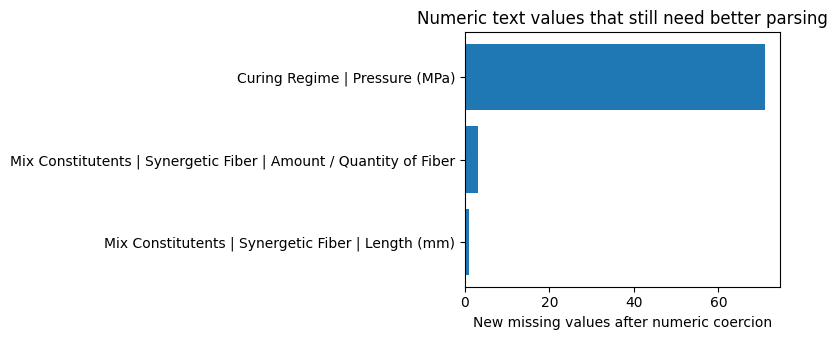

In [5]:
base_X = target_df[candidate_features].copy()
base_X, numeric_coercion_report = coerce_numeric_features(base_X)

changed_numeric = numeric_coercion_report.query(
    "new_missing_from_numeric_coercion > 0"
).sort_values("new_missing_from_numeric_coercion", ascending=False)

display(numeric_coercion_report)
display(changed_numeric)

if not changed_numeric.empty:
    plt.figure(figsize=(8, 3.5))
    plt.barh(changed_numeric["column"], changed_numeric["new_missing_from_numeric_coercion"])
    plt.xlabel("New missing values after numeric coercion")
    plt.title("Numeric text values that still need better parsing")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


### Interpretation

Most numeric columns convert cleanly. The main problem is curing pressure, where many text-like values are not parsed as numbers yet. In the current generated datasets, pressure becomes fully missing and is dropped from the `full_raw` modelling table after train-only preprocessing.

This is a useful finding for the next improvement: parse numeric values embedded in text before coercion.

## Strategy 3 - Compare three raw missingness policies

I created three feature policies before semantic recoding:

| Policy | Meaning |
|---|---|
| `full_raw` | Keep all safe candidate columns, even if highly missing. |
| `raw_le_50` | Keep only columns with at most 50% raw missingness. |
| `raw_le_20` | Keep only columns with at most 20% raw missingness. |

The threshold is applied before semantic recoding. That makes the policies easy to compare, but it also means some type columns can be dropped before the semantic rules have a chance to rescue them.

,policy,missing_threshold_before_semantic_recode,features_before_policy,features_after_policy,features_dropped_by_policy,semantic_recode_applied
0,full_raw,NaN,42,42,0,True
1,raw_le_50,0.5,42,29,13,True
2,raw_le_20,0.2,42,24,18,True


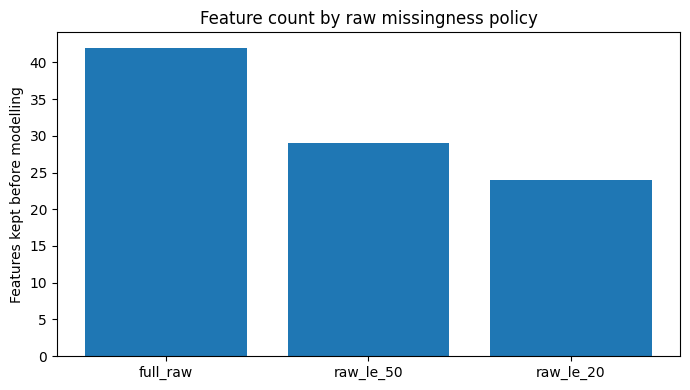

In [6]:
policy_frames = {}
policy_feature_tables = []
policy_missing_reports = []
policy_semantic_summaries = []
policy_rows = []

for policy_name, policy_config in config["policies"].items():
    selected_features, feature_table = filter_features_by_missingness(
        df=base_X,
        features=list(base_X.columns),
        missing_threshold=policy_config.get("missing_threshold"),
    )
    X_before_recode = base_X[selected_features].copy()
    if policy_config.get("apply_semantic_recode", True):
        X_after_recode, semantic_summary = recode_semantic_missingness(X_before_recode)
    else:
        X_after_recode = X_before_recode.copy()
        semantic_summary = pd.DataFrame()

    missing_report = make_missing_before_after_report(X_before_recode, X_after_recode)

    feature_table.insert(0, "policy", policy_name)
    missing_report.insert(0, "policy", policy_name)
    if not semantic_summary.empty:
        semantic_summary.insert(0, "policy", policy_name)

    policy_frames[policy_name] = X_after_recode
    policy_feature_tables.append(feature_table)
    policy_missing_reports.append(missing_report)
    policy_semantic_summaries.append(semantic_summary)
    policy_rows.append(
        {
            "policy": policy_name,
            "missing_threshold_before_semantic_recode": policy_config.get("missing_threshold"),
            "features_before_policy": base_X.shape[1],
            "features_after_policy": len(selected_features),
            "features_dropped_by_policy": base_X.shape[1] - len(selected_features),
            "semantic_recode_applied": policy_config.get("apply_semantic_recode", True),
        }
    )

policy_summary = pd.DataFrame(policy_rows)
feature_policy_missingness = pd.concat(policy_feature_tables, ignore_index=True)
policy_missing_before_after = pd.concat(policy_missing_reports, ignore_index=True)
policy_semantic_summary = pd.concat(policy_semantic_summaries, ignore_index=True)

display(policy_summary)

plt.figure(figsize=(7, 4))
plt.bar(policy_summary["policy"], policy_summary["features_after_policy"])
plt.ylabel("Features kept before modelling")
plt.title("Feature count by raw missingness policy")
plt.tight_layout()
plt.show()


In [7]:
dropped_by_threshold = feature_policy_missingness.query("kept == False").copy()
dropped_by_threshold = dropped_by_threshold.sort_values(
    ["policy", "missing_percentage_before_semantic_recode"],
    ascending=[True, False],
)

display(
    dropped_by_threshold[[
        "policy",
        "feature",
        "missing_percentage_before_semantic_recode",
        "drop_reason",
    ]]
)


,policy,feature,missing_percentage_before_semantic_recode,drop_reason
125,raw_le_20,Curing Regime | Pressure (MPa),100.000000,missing_fraction_above_0.2
118,raw_le_20,"Mix Constitutents | Synergetic Fiber | Nominal Young’s modulus, Gpa",97.202123,missing_fraction_above_0.2
97,raw_le_20,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Type of Slag,95.561987,missing_fraction_above_0.2
117,raw_le_20,Mix Constitutents | Synergetic Fiber | Tensile Strength (MPa),95.561987,missing_fraction_above_0.2
113,raw_le_20,Mix Constitutents | Synergetic Fiber | Type of Fiber,94.307767,missing_fraction_above_0.2
114,raw_le_20,Mix Constitutents | Synergetic Fiber | Amount / Quantity of Fiber,94.307767,missing_fraction_above_0.2
115,raw_le_20,Mix Constitutents | Synergetic Fiber | Length (mm),94.307767,missing_fraction_above_0.2
116,raw_le_20,Mix Constitutents | Synergetic Fiber | Diameter (mm),94.307767,missing_fraction_above_0.2
112,raw_le_20,"Mix Constitutents | Fiber | Nominal Young’s modulus, Gpa",83.984563,missing_fraction_above_0.2
103,raw_le_20,Mix Constitutents | Sustainable Filler | Type of Filler,82.633864,missing_fraction_above_0.2


## Strategy 4 - Semantic missingness for amount/type pairs

The most important Week 6 idea is that missingness is not always the same thing.

For a material amount/type pair:

| Case | Recoding used |
|---|---|
| amount > 0 and type missing | type becomes `unknown_type` because material was used but type was not reported. |
| amount missing and type present | amount stays missing because the material exists but quantity is unknown. |
| amount missing or amount = 0, and type missing | amount becomes `0` and type becomes `not_applicable`. |

Configured pairs: cement, fly ash, slag, sustainable filler, sand, fiber, synergetic fiber, and superplasticizer.

In [8]:
semantic_display_columns = [
    "policy",
    "pair",
    "applied",
    "reason",
    "amount_missing_before",
    "type_missing_before",
    "amount_positive_type_missing_to_unknown_type",
    "amount_zero_or_missing_type_missing_to_not_applicable",
    "type_present_amount_missing_left_missing",
    "amount_missing_after",
    "type_missing_after",
    "unknown_type_after",
    "not_applicable_after",
]

display(policy_semantic_summary[semantic_display_columns])


,policy,pair,applied,reason,amount_missing_before,type_missing_before,amount_positive_type_missing_to_unknown_type,amount_zero_or_missing_type_missing_to_not_applicable,type_present_amount_missing_left_missing,amount_missing_after,type_missing_after,unknown_type_after,not_applicable_after
0,full_raw,cement,True,semantic_rules_applied,0.0,19.0,19.0,0.0,0.0,0.0,0.0,19.0,0.0
1,full_raw,fly_ash,True,semantic_rules_applied,0.0,1648.0,12.0,1636.0,0.0,0.0,0.0,12.0,1636.0
2,full_raw,slag,True,semantic_rules_applied,0.0,1981.0,4.0,1977.0,0.0,0.0,0.0,4.0,1977.0
3,full_raw,sustainable_filler,True,semantic_rules_applied,0.0,1713.0,0.0,1713.0,0.0,0.0,0.0,0.0,1713.0
4,full_raw,sand,True,semantic_rules_applied,0.0,82.0,16.0,66.0,0.0,0.0,0.0,16.0,66.0
5,full_raw,fiber,True,semantic_rules_applied,669.0,669.0,0.0,669.0,0.0,0.0,0.0,0.0,669.0
6,full_raw,synergetic_fiber,True,semantic_rules_applied,1955.0,1955.0,0.0,1955.0,0.0,0.0,0.0,0.0,1955.0
7,full_raw,superplasticizer,True,semantic_rules_applied,8.0,120.0,120.0,0.0,8.0,8.0,0.0,120.0,0.0
8,raw_le_50,cement,True,semantic_rules_applied,0.0,19.0,19.0,0.0,0.0,0.0,0.0,19.0,0.0
9,raw_le_50,fly_ash,False,amount_or_type_column_not_in_policy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,column,missing_before,missing_after,missing_reduced_by
2,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Type of Slag,1981,0,1981
4,Mix Constitutents | Synergetic Fiber | Amount / Quantity of Fiber,1955,0,1955
7,Mix Constitutents | Synergetic Fiber | Type of Fiber,1955,0,1955
9,Mix Constitutents | Sustainable Filler | Type of Filler,1713,0,1713
10,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Fly Ash Type,1648,0,1648
17,Mix Constitutents | Fiber | Type of Fiber,669,0,669
16,Mix Constitutents | Fiber | Amount / Quantity of Fiber,669,0,669
20,Mix Constitutents | Superplasticizer | Type of Superplasticizer,120,0,120
21,Mix Constitutents | Sand | Sand Type,82,0,82
22,Mix Constitutents | Binder | Cement type,19,0,19


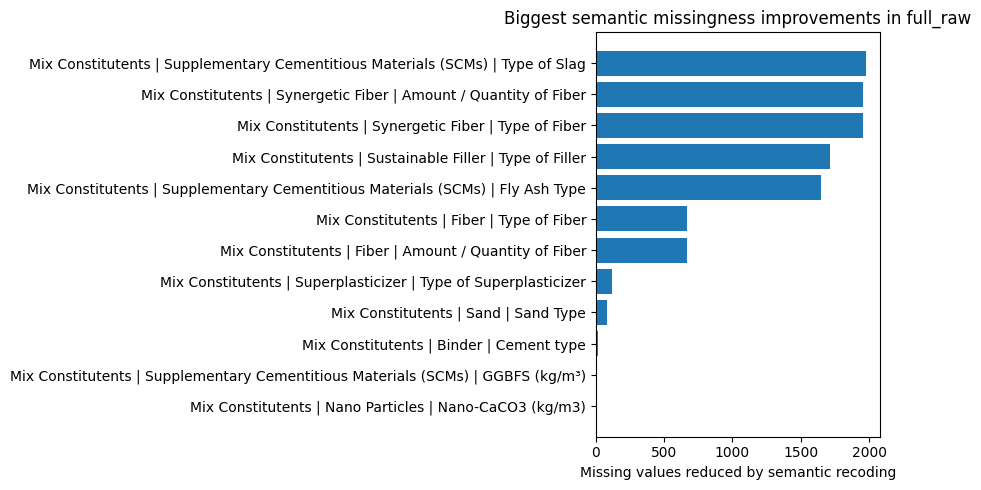

In [9]:
full_raw_missing_reduction = (
    policy_missing_before_after
    .query("policy == 'full_raw'")
    .sort_values("missing_reduced_by", ascending=False)
    .head(12)
)

display(full_raw_missing_reduction[[
    "column",
    "missing_before",
    "missing_after",
    "missing_reduced_by",
]])

plt.figure(figsize=(9, 5))
plt.barh(full_raw_missing_reduction["column"], full_raw_missing_reduction["missing_reduced_by"])
plt.xlabel("Missing values reduced by semantic recoding")
plt.title("Biggest semantic missingness improvements in full_raw")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretation

Semantic recoding is especially useful for type columns. A blank fly-ash type, slag type, filler type, or fiber type often means the material was not used, not that the dataset randomly forgot a category.

This keeps the model from treating meaningful absence as ordinary missingness.

## Strategy 5 - Reproducible train/validation/test split

The current Week 6 workflow uses a random row split:

- 70% train
- 15% validation
- 15% test
- random seed = 42

This gives a fixed split for comparing preprocessing policies. It is useful for initial experiments, but it is not the final best evaluation design for this dataset because many rows share the same `Mix-ID` or duplicate information.

In [10]:
y = target_df[target_col].copy()
split_config = config["split"]
splits = {}
split_rows = []

for policy_name, X_policy in policy_frames.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
        X=X_policy,
        y=y,
        val_size=split_config["val_size"],
        test_size=split_config["test_size"],
        random_state=split_config["random_state"],
    )
    splits[policy_name] = (X_train, X_val, X_test, y_train, y_val, y_test)
    split_rows.append(
        {
            "policy": policy_name,
            "rows_total": len(X_policy),
            "train_rows": len(X_train),
            "validation_rows": len(X_val),
            "test_rows": len(X_test),
        }
    )

split_summary = pd.DataFrame(split_rows)
display(split_summary)


,policy,rows_total,train_rows,validation_rows,test_rows
0,full_raw,2073,1451,311,311
1,raw_le_50,2073,1451,311,311
2,raw_le_20,2073,1451,311,311


In [11]:
def audit_row_random_split(X_policy, split_tuple):
    """Audit whether Mix-ID groups or exact duplicates cross split boundaries."""
    X_train, X_val, X_test, y_train, y_val, y_test = split_tuple
    assignment = pd.Series(index=X_policy.index, dtype="object")
    assignment.loc[X_train.index] = "train"
    assignment.loc[X_val.index] = "validation"
    assignment.loc[X_test.index] = "test"

    audit = pd.DataFrame(
        {
            "Mix-ID": target_df.loc[X_policy.index, "Mix-ID"].astype(str),
            "split": assignment.loc[X_policy.index],
        }
    )
    mix_split_counts = audit.groupby("Mix-ID")["split"].nunique()
    crossing_mix_ids = mix_split_counts[mix_split_counts > 1].index

    duplicate_key = pd.util.hash_pandas_object(
        pd.concat([X_policy, y.rename(target_col)], axis=1),
        index=False,
    )
    duplicate_audit = pd.DataFrame({"duplicate_key": duplicate_key, "split": assignment})
    duplicate_group_sizes = duplicate_audit.groupby("duplicate_key").size()
    duplicate_split_counts = duplicate_audit.groupby("duplicate_key")["split"].nunique()
    crossing_duplicate_keys = duplicate_split_counts[
        (duplicate_split_counts > 1) & (duplicate_group_sizes > 1)
    ].index

    return {
        "mix_ids_crossing_splits": len(crossing_mix_ids),
        "rows_in_crossing_mix_ids": int(audit["Mix-ID"].isin(crossing_mix_ids).sum()),
        "exact_duplicate_groups_crossing_splits": len(crossing_duplicate_keys),
        "rows_in_crossing_duplicate_groups": int(
            duplicate_audit["duplicate_key"].isin(crossing_duplicate_keys).sum()
        ),
    }

full_raw_split_audit = audit_row_random_split(policy_frames["full_raw"], splits["full_raw"])
display(pd.DataFrame([full_raw_split_audit]))


,mix_ids_crossing_splits,rows_in_crossing_mix_ids,exact_duplicate_groups_crossing_splits,rows_in_crossing_duplicate_groups
0,203,722,8,16


### Important limitation

The current row-random split is reproducible, but it is not group-aware. If the same `Mix-ID` appears in train and validation/test, performance can look better than it should.

For final model evaluation, the next methodological fix should be a grouped split by `Mix-ID` or paper source.

## Strategy 6 - Train-fitted preprocessing for modelling

After splitting, preprocessing is built from the training data only.

Numeric strategy currently used:

- detect known numeric UHPC feature columns
- drop numeric columns that are fully missing in training
- median imputation using training data
- add missing indicators
- standardize with `StandardScaler`

Categorical strategy currently used:

- fill residual missing categories with `missing_reported_gap`
- low-cardinality features: one-hot encoding with unknown categories ignored
- medium-cardinality features: rare-category one-hot encoding
- high-cardinality features: domain grouping, then rare-category one-hot encoding

Target encoding is available in the code, but it is disabled in the current Week 6 config.

In [12]:
preprocessing_config = config.get("preprocessing", {})
preprocessor_builds = {}
preprocessing_rows = []
cardinality_reports = []
numeric_audits = []

for policy_name, split_tuple in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_tuple

    build = build_week6_preprocessor(
        X_train=X_train,
        y_train=y_train,
        numeric_imputer=preprocessing_config.get("numeric_imputer", "simple"),
        numeric_add_indicator=preprocessing_config.get("numeric_add_indicator", True),
        knn_neighbors=preprocessing_config.get("knn_neighbors", 5),
        low_cardinality_max=preprocessing_config.get("low_cardinality_max", 10),
        medium_cardinality_max=preprocessing_config.get("medium_cardinality_max", 20),
        high_cardinality_policy="grouped_ohe",
        random_state=split_config["random_state"],
    )

    X_train_model = X_train.drop(columns=build.dropped_numeric_features)
    X_val_model = X_val.drop(columns=build.dropped_numeric_features)
    X_test_model = X_test.drop(columns=build.dropped_numeric_features)

    preprocessor = build.preprocessor
    Xt_train = preprocessor.fit_transform(X_train_model, y_train)
    Xt_val = preprocessor.transform(X_val_model)
    Xt_test = preprocessor.transform(X_test_model)

    preprocessor_builds[policy_name] = {
        "build": build,
        "preprocessor": preprocessor,
        "X_train_model": X_train_model,
        "X_val_model": X_val_model,
        "X_test_model": X_test_model,
        "Xt_train": Xt_train,
        "Xt_val": Xt_val,
        "Xt_test": Xt_test,
    }

    summary = build.preprocessing_summary.copy()
    summary.insert(0, "policy", policy_name)
    summary["modeling_features_after_drops"] = X_train_model.shape[1]
    summary["transformed_train_columns"] = Xt_train.shape[1]
    summary["remaining_nan_train"] = int(np.isnan(Xt_train).sum())
    summary["remaining_nan_validation"] = int(np.isnan(Xt_val).sum())
    summary["remaining_nan_test"] = int(np.isnan(Xt_test).sum())
    preprocessing_rows.append(summary)

    cardinality_report = build.cardinality_report.copy()
    cardinality_report.insert(0, "policy", policy_name)
    cardinality_reports.append(cardinality_report)

    numeric_audit = build.numeric_missing_audit.copy()
    numeric_audit.insert(0, "policy", policy_name)
    numeric_audits.append(numeric_audit)

preprocessing_summary = pd.concat(preprocessing_rows, ignore_index=True)
categorical_cardinality_report = pd.concat(cardinality_reports, ignore_index=True)
numeric_fully_missing_audit = pd.concat(numeric_audits, ignore_index=True)

display(preprocessing_summary[[
    "policy",
    "input_features",
    "numeric_features_detected",
    "numeric_features_dropped_fully_missing_train",
    "numeric_features_used",
    "categorical_features_detected",
    "low_cardinality_features",
    "medium_cardinality_features",
    "high_cardinality_features",
    "modeling_features_after_drops",
    "transformed_train_columns",
    "remaining_nan_train",
    "remaining_nan_validation",
    "remaining_nan_test",
]])


,policy,input_features,numeric_features_detected,numeric_features_dropped_fully_missing_train,numeric_features_used,categorical_features_detected,low_cardinality_features,medium_cardinality_features,high_cardinality_features,modeling_features_after_drops,transformed_train_columns,remaining_nan_train,remaining_nan_validation,remaining_nan_test
0,full_raw,42,33,1,32,9,2,2,5,41,124,0,0,0
1,raw_le_50,29,24,0,24,5,0,0,5,29,83,0,0,0
2,raw_le_20,24,20,0,20,4,0,0,4,24,71,0,0,0


In [13]:
display(
    numeric_fully_missing_audit.query("dropped_from_modeling == True")[[
        "policy",
        "column",
        "missing_fraction_train",
        "drop_reason",
    ]]
)


,policy,column,missing_fraction_train,drop_reason
32,full_raw,Curing Regime | Pressure (MPa),1.0,numeric_fully_missing_in_X_train


,policy,column,missing_count_train,missing_fraction_train,unique_categories_train,cardinality_bucket,encoder_policy,low_cardinality_max,medium_cardinality_max
0,full_raw,Mix Constitutents | Binder | Cement type,0,0.0,133,high,domain_grouping_then_rare_category_onehot,10,20
1,full_raw,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Fly Ash Type,0,0.0,8,low,onehot_ignore_unknown,10,20
2,full_raw,Mix Constitutents | Supplementary Cementitious Materials (SCMs) | Type of Slag,0,0.0,6,low,onehot_ignore_unknown,10,20
3,full_raw,Mix Constitutents | Sustainable Filler | Type of Filler,0,0.0,20,medium,rare_category_onehot,10,20
4,full_raw,Mix Constitutents | Sand | Sand Type,0,0.0,28,high,domain_grouping_then_rare_category_onehot,10,20
5,full_raw,Mix Constitutents | Fiber | Type of Fiber,0,0.0,45,high,domain_grouping_then_rare_category_onehot,10,20
6,full_raw,Mix Constitutents | Synergetic Fiber | Type of Fiber,0,0.0,14,medium,rare_category_onehot,10,20
7,full_raw,Mix Constitutents | Superplasticizer | Type of Superplasticizer,0,0.0,120,high,domain_grouping_then_rare_category_onehot,10,20
8,full_raw,Curing Regime | Curing,0,0.0,42,high,domain_grouping_then_rare_category_onehot,10,20
9,raw_le_50,Mix Constitutents | Binder | Cement type,0,0.0,133,high,domain_grouping_then_rare_category_onehot,10,20


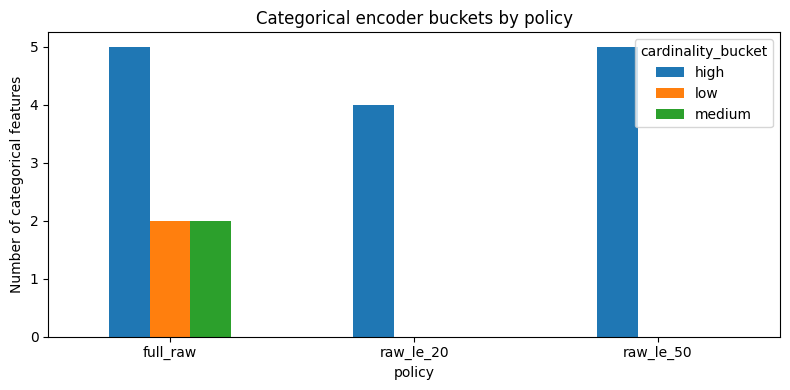

In [14]:
display(categorical_cardinality_report)

cardinality_counts = (
    categorical_cardinality_report
    .groupby(["policy", "cardinality_bucket"])
    .size()
    .unstack(fill_value=0)
)

cardinality_counts.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Number of categorical features")
plt.title("Categorical encoder buckets by policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## How to interpret the three Week 6 datasets

| Dataset | What it tests | Main trade-off |
|---|---|---|
| `full_raw` | Maximum feature retention after leakage exclusion. | Keeps sparse columns, so preprocessing must handle many gaps. |
| `raw_le_50` | Balanced retention with a moderate raw missingness threshold. | Drops very sparse type/attribute columns before semantic recoding. |
| `raw_le_20` | Conservative feature set with only well-reported columns. | Lowest noise, but may lose useful domain information. |

For Week 6, I would present `raw_le_50` as the balanced candidate and keep `full_raw` plus `raw_le_20` as comparison strategies.

## Strategies used versus options available

| Strategy | Current Week 6 status |
|---|---|
| Semantic amount/type recoding | Used |
| Raw missingness policy comparison | Used |
| Median numeric imputation | Used |
| Numeric missing indicators | Used |
| Standard scaling | Used |
| Cardinality-aware one-hot encoding | Used |
| Domain grouping for high-cardinality categories | Used |
| KNN imputation | Available, not used in current config |
| Target encoding for high-cardinality categories | Available, disabled in current config |
| Group-aware split by `Mix-ID` | Not used yet; should be next improvement |
| Numeric text parser for values like curing pressure | Not used yet; should be next improvement |


## Reproducing the generated Week 6 files

I have generated these dataset folders:

```text
data/processed/week6/full_raw/
data/processed/week6/raw_le_50/
data/processed/week6/raw_le_20/
```

Each folder contains `X_train.csv`, `X_val.csv`, `X_test.csv`, `y_train.csv`, `y_val.csv`, `y_test.csv`, and policy-specific audit files.

## Limitations to mention honestly

These are not failures; they are the next engineering tasks before final model claims.

1. The split is currently row-random, not group-aware. Some `Mix-ID` groups cross split boundaries.
2. Numeric text parsing is incomplete. Curing pressure currently becomes fully missing after numeric coercion.
3. Dependent fiber attributes such as length, diameter, and tensile strength are not yet semantically set to zero when fiber is absent.
4. The rule `amount missing + type missing = not used` is a strong domain assumption. It may sometimes mean not reported.
5. Physical-range validation is not yet included, so impossible negative or extreme values are not flagged here.
